In [49]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
                         21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
                         23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
                         27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
                         39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
                         44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
                         115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
                         150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
                         218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
                         556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
                         850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
                         1000.0])

<function matplotlib.pyplot.show(close=None, block=None)>

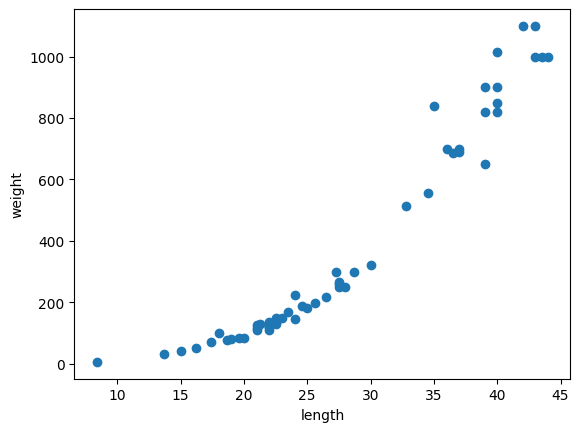

In [50]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show

- k-최근접 이웃 분류 알고리즘
    - 예측하려는 샘플에 가장 가까운 샘플 k개 선택
    - 이 샘플들의 클래스 확인 -> 다수의 클래스를 새로운 샘플의 클래스로 예측
- k-최근접 이웃 회귀 알고리즘
    - 예측하려는 샘플에 가장 가까운 샘플 k개 선택
    - 이웃한 샘플의 타깃: 클래스X, 임의의 수치
    - 이웃 샘플 수치 사용 -> 새로운 샘플 타깃 예측 위해 수치들의 평균 구함

In [51]:
# 훈련 데이터 & 테스트 데이터로 나누기

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

In [52]:
# 사이킷런의 훈련 세트는 2차원 배열 필요
# 2장에서는 2개의 특성 사용 -> 열이 2개인 2차원 배열 사용
# reshape() 함수 사용해 2차원 배열로 만들어줌

train_input = train_input.reshape(-1, 1)    # 크기에 -1: 나머지 원소 개수로 모두 채워라
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


In [53]:
# 사이킷런에서 k-최근접 이웃 회귀 알고리즘 구현은 KNeighborsRegressor

from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

# 테스트 세트의 점수: 결정계수
print(knr.score(test_input, test_target))

0.992809406101064


- 결정계수($R^2$)
    - $R^2 = \dfrac{(타깃 - 예측)^2의 합}{(타깃 - 평균)^2의 합}$
    - if 타깃의 평균 정도 예측하는 수준(분자와 분모 비슷):
        - $R^2$ 0에 가까워짐
    - if 예측이 타깃에 아주 가까워짐(분자가 0에 가까워짐):
        - $R^2$ 1에 가까워짐
    - 타깃과 예측한 값 사이 차이 구해 어느 정도 예측에서 벗어났는지 평가

In [54]:
from sklearn.metrics import mean_absolute_error     # 이거 좀 중요하대..

# 테스트 세트에 대한 예측 생성
test_prediction = knr.predict(test_input)

# 테스트 세트에 대한 평균 절댓값 오차 계산
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


- 과대적합 vs 과소적합
    - k-최근접 이웃 회귀 알고리즘에서는 훈련 세트와 테스트 세트에서 평가하면 두 값 중 보통 훈련 세트의 점수가 좀 더 높음
    - 과대적합
        - 훈련 세트에서 점수가 좋았는데 테스트 세트에서 점수가 나쁜 경우
        - 훈련 세트에만 잘 맞는 모델이라 테스트 세트 & 나중에 실전에 투입하여 새로운 샘플에 대한 예측 만들 때 부적합
    - 과소적합
        - 훈련 세트보다 테스트 세트의 점수 높음 or 두 점수 모두 너무 낮음
        - 모델 너무 단순 -> 훈련 세트에서 적절히 훈련되지 않음

In [55]:
# 이웃의 계수 3으로 설정
knr.n_neighbors = 3

# 모델 재훈련
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9804899950518966
0.9746459963987609


- 문제
    - 농어의 높이, 길이 등의 수치로 무게를 예측하기(회귀는 임의의 수치를 예측)
- 해결
    - k-최근접 이웃 회귀 모델은 분류와 동일하게 가장 먼저 가까운 k개의 이웃을 찾아 이웃 샘플의 타깃값을 평균하여 이 샘플의 예측값으로 사용
    - 사이킷런은 회귀 모델의 점수로 $R^2$, 즉 결정계수 값을 반환. 이 값은 1에 가까울수록 좋음
    - 정량적인 평가는 사이킷런에서 제공하는 다른 평가 도구를 사용할 수 있음(대표적으로 절댓값 오차)
    - 모델을 훈련하고 나서 훈련 세트와 테스트 세트에 대해 모두 평가 점수를 구할 수 있음
        - 훈련 세트의 점수와 테스트 세트의 점수 차이가 크면 좋지 않음
        - 일반적으로 훈련 세트의 점수가 테스트 세트보다 조금 더 높음
    - 과대적합: 만약 테스트 세트의 점수가 너무 낮다면 모델이 훈련 세트에 과도하게 맞춰짐
    - 과소적합: 테스트 세트 점수가 너무 높거나 두 점수가 모두 낮은 경우
    - 과대적합일 경우 모델을 덜 복잡하게 만들어야 함(k-최근접 이웃의 경우 k 값을 늘림)
    - 과소적합일 경우 모델을 더 복잡하게 만들어 줌(k-최근접 이웃의 경우 k 값을 줄임)
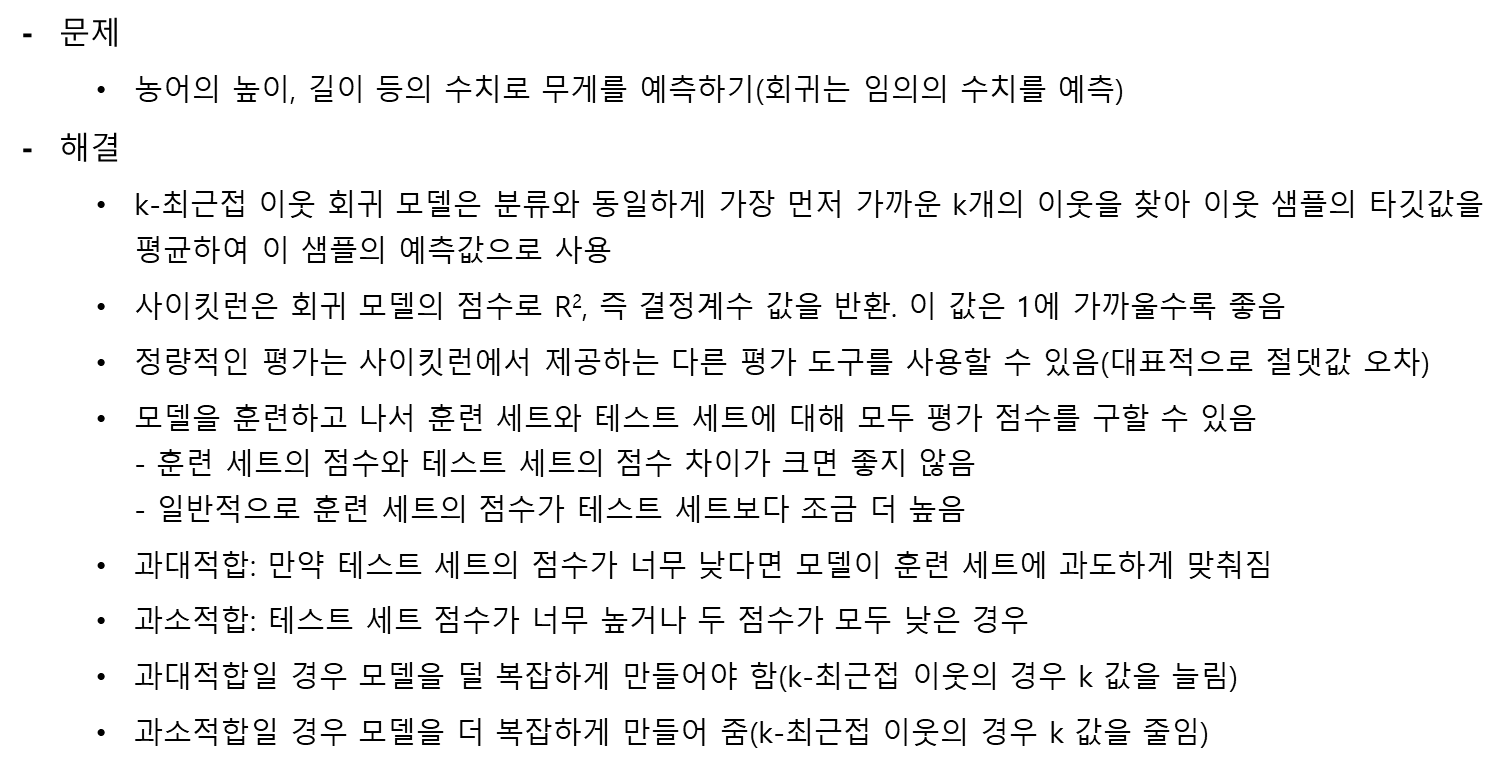
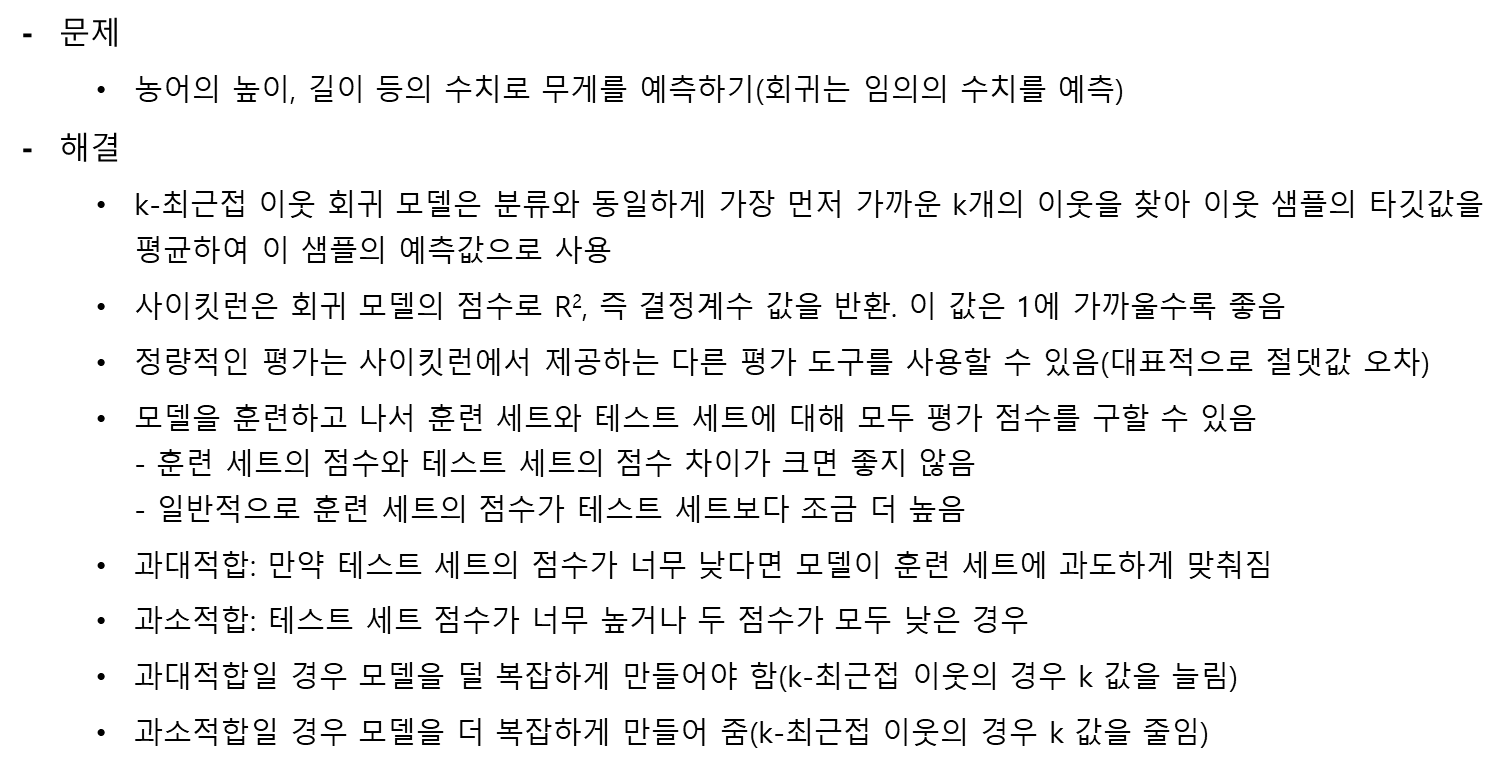
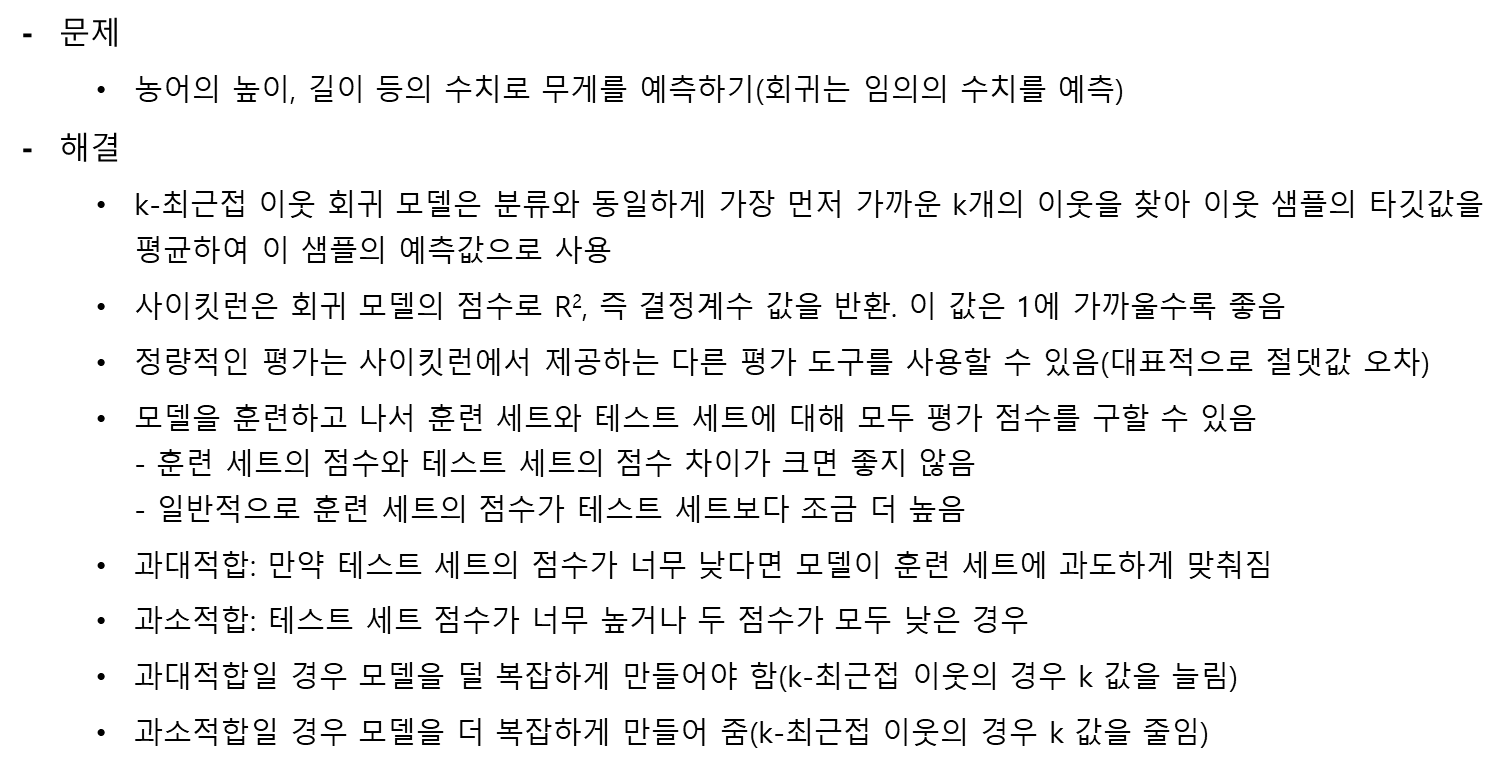

In [56]:
from sklearn.model_selection import train_test_split

# 훈련 세트와 테스트 세트로 나눔
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

# 훈련 세트와 테스트 세트를 2차원 배열로 변경
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# 최근접 이웃 개수를 3으로 하는 모델 훈련
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)

# k-최근접 이웃 회귀 모델 훈련
knr.fit(train_input, train_target)
print(knr.predict([[50]]))

[1033.33333333]


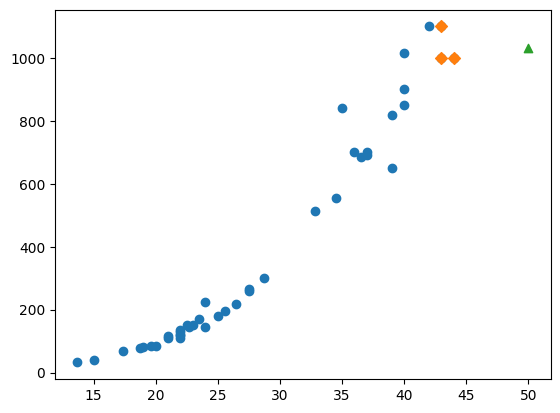

In [57]:
# 50cm 농어의 이웃 구하기
distances, indexes= knr.kneighbors([[50]])

# 훈련 세트의 산점도 그림
plt.scatter(train_input, train_target)

# 훈련 세트 중 이웃 샘플만 다시 그림
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 농어 데이터
plt.scatter(50, 1033, marker='^')
plt.show()

- 선형 회귀(linear regression)
    - 특성이 하나인 경우 어떤 직선을 학습하는 알고리즘

In [58]:
# sklearn.linear_model 패키지 아래에 LinearRegression 클래스로 선형 회귀 알고리즘 구현

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# 선형회귀 모델 훈련
lr.fit(train_input, train_target)

# 50cm 농어에 대해 예측
print(lr.predict([[50]]))

[1241.83860323]


In [59]:
# LinearRegression 클래스가 찾은 기울기(a) & 절편(b)

print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


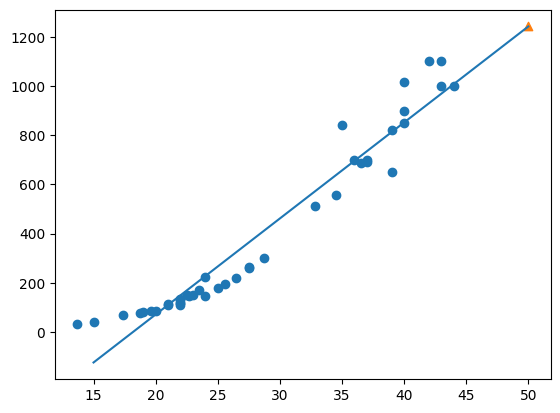

0.9398463339976041
0.824750312331356


In [60]:
# 농어의 길이를 15에서 50까지 직선으로 나타내고 훈련 세트의 산점도 확인

# 훈련 데이터의 산점도 그림
plt.scatter(train_input, train_target)

# 15에서 50까지 1차 방정식 그래프를 그림
plt.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='^')
plt.show()

print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

- 다항 회귀(polynomial regression)
    - 최적의 곡선 탐색
    - ![1](img/chapter03-1.png)

In [63]:
# 농어의 길이를 제곱 -> 원래 데이터 앞에 추가
# column_stack() 함수 사용: train_input을 제곱한 것 & train_input 두 배열 나란히 붙임
trian_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

# 데이터셋 크기 확인
print(trian_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [64]:
# train_poly 사용해 선형회귀 모델 재훈련

lr = LinearRegression()
lr.fit(trian_poly, train_target)
print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [65]:
# 모델이 훈련한 계수 & 절편 출력
print(lr.coef_, lr.intercept_)

"""
결과: [  1.01433211 -21.55792498] 116.05021078278264
모델이 학습한 그래프: 무게 = 1.01 × 길이² - 21.6 × 길이 + 116.05
"""

[  1.01433211 -21.55792498] 116.05021078278264


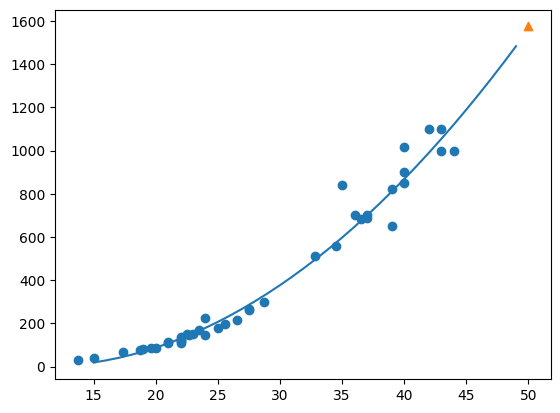

In [67]:
# 훈련 세트의 산점도 그래프로 그리고 짧은 직선 이어 그려 곡선으로 표현

# 구간별 직선 그리기 위해 15 ~ 49 점수 배열 만듦
point = np.arange(15, 50)

# 훈련 세트의 산점도 그림
plt.scatter(train_input, train_target)

# 15 ~ 49 2차방정식 그래프 그림
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)

# 50cm 농어 데이터
plt.scatter(50, 1574, marker='^')
plt.show()

In [68]:
# 훈련 세트 & 테스트 세트의 R² 점수 평가
print(lr.score(trian_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


- 선형회귀 실제로 하는 일
    - 어떤 w와 b를 선택해야 예측이 실제값과 가장 비슷?
    - $\hat{y} = wx + b$
        - 어떤 기울기 w, 절편 b를 학습해야 실제 값과 가장 비슷?
        - 오차를 줄이는 방식으로
            - $오차 = \hat{y} - y$
        - 오차의 값은 음수 나올 수 있음 -> 오차의 제곱 사용
    - 손실 함수
        - 선형회귀에서는 전체 데이터에 대해 오차 제곱합을 최소화하는 w, b를 찾는 과정
        - $\sum^{n}_{i=1}(y_i - \hat{y_i})^2$: RSS(Residual Sum of Square
        - 혹은
        - $\frac{1}{n} \sum^n_{i=1}(y_i) - \hat{y_i})^2$: MSE(Mean Square Error)
    - 찾는 방법
        - 미분 통해 수학적으로
        - 경사 하강법처럼 반복적으로 -> 큰 데이터에서 많이 사용